# Complete Component One: Streaming Service Analysis Solution

This notebook contains the complete solution for all parts (a-h) of Component One, including regression models, neural networks, classification, and clustering with proper handling of string columns like Customer_ID.

In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [2]:
# Load the dataset
df = pd.read_csv("Streaming.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 12)


,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0


## Data Cleaning and Preprocessing

In [3]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Fill missing values appropriately
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(df["Satisfaction_Score"].median())

# Check data types
print("\nData types:")
print(df.dtypes)

# Remove duplicates
df_clean = df.drop_duplicates()
print(f"\nShape after removing duplicates: {df_clean.shape}")

# Basic statistics for numeric columns
print("\nBasic statistics:")
df_clean.describe()

Missing values in each column:
Customer_ID                 0
Age                       500
Gender                      0
Subscription_Length         0
Region                      0
Payment_Method              0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

Data types:
Customer_ID                object
Age                       float64
Gender                     object
Subscription_Length         int64
Region                     object
Payment_Method             object
Support_Tickets_Raised      int64
Satisfaction_Score        float64
Discount_Offered          float64
Last_Activity               int64
Monthly_Spend             float64
Churned                     int64
dtype: object

Shape after removing duplicates: (5000, 12)

Basic statistics:


,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.524000,29.704400,2.037000,5.591400,12.458404,181.441400,46.619784,0.448000
std,14.202287,17.050336,1.422405,2.725423,4.325381,104.500951,9.522140,0.497338
min,18.000000,1.000000,0.000000,1.000000,5.000000,1.000000,-5.060000,0.000000
25%,32.000000,15.000000,1.000000,3.000000,8.700000,90.000000,39.897500,0.000000
50%,43.000000,29.000000,2.000000,6.000000,12.500000,182.000000,46.625000,0.000000
75%,55.000000,44.000000,3.000000,8.000000,16.190000,271.000000,53.210000,1.000000
max,69.000000,59.000000,9.000000,10.000000,20.000000,364.000000,137.310000,1.000000


## Part (a): Regression Models with Single Numerical Feature

Compare regression models that predict "Monthly Spend" based on a single numerical feature.

In [4]:
def evaluate_single_feature_regression(feature, X, y):
    """
    Evaluate linear and polynomial regression for a single feature.
    
    Parameters:
    - feature: Name of the feature being analyzed
    - X: DataFrame with the feature as a column
    - y: Series with the target values (Monthly_Spend)
    
    Returns:
    - Dictionary with evaluation metrics
    """
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    # Make predictions
    y_pred_linear = lr.predict(X_test)
    
    # Calculate metrics
    rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
    r2_linear = r2_score(y_test, y_pred_linear)
    
    # Polynomial Regression (degree 2)
    poly = PolynomialFeatures(degree=2)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_poly_train, y_train)
    
    # Make predictions
    y_pred_poly = lr_poly.predict(X_poly_test)
    
    # Calculate metrics
    rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    r2_poly = r2_score(y_test, y_pred_poly)
    
    # Plot the results
    plt.figure(figsize=(14, 6))
    
    # Scatter plot of actual data
    plt.subplot(1, 2, 1)
    plt.scatter(X_test, y_test, color='blue', label='Actual data')
    
    # Sort X_test for smooth line plot
    sort_idx = np.argsort(X_test.values.flatten())
    X_sorted = X_test.values.flatten()[sort_idx]
    
    # Linear regression line
    plt.plot(X_sorted, y_pred_linear[sort_idx], color='red', label='Linear Regression')
    plt.title(f'Linear Regression: {feature} vs Monthly Spend')
    plt.xlabel(feature)
    plt.ylabel('Monthly Spend')
    plt.legend()
    
    # Polynomial regression
    plt.subplot(1, 2, 2)
    plt.scatter(X_test, y_test, color='blue', label='Actual data')
    
    # Create sorted X values for smooth polynomial curve
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range_poly = lr_poly.predict(X_range_poly)
    
    plt.plot(X_range, y_range_poly, color='green', label='Polynomial Regression')
    plt.title(f'Polynomial Regression: {feature} vs Monthly Spend')
    plt.xlabel(feature)
    plt.ylabel('Monthly Spend')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Return evaluation metrics
    return {
        'feature': feature,
        'linear_rmse': rmse_linear,
        'linear_r2': r2_linear,
        'poly_rmse': rmse_poly,
        'poly_r2': r2_poly
    }

/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


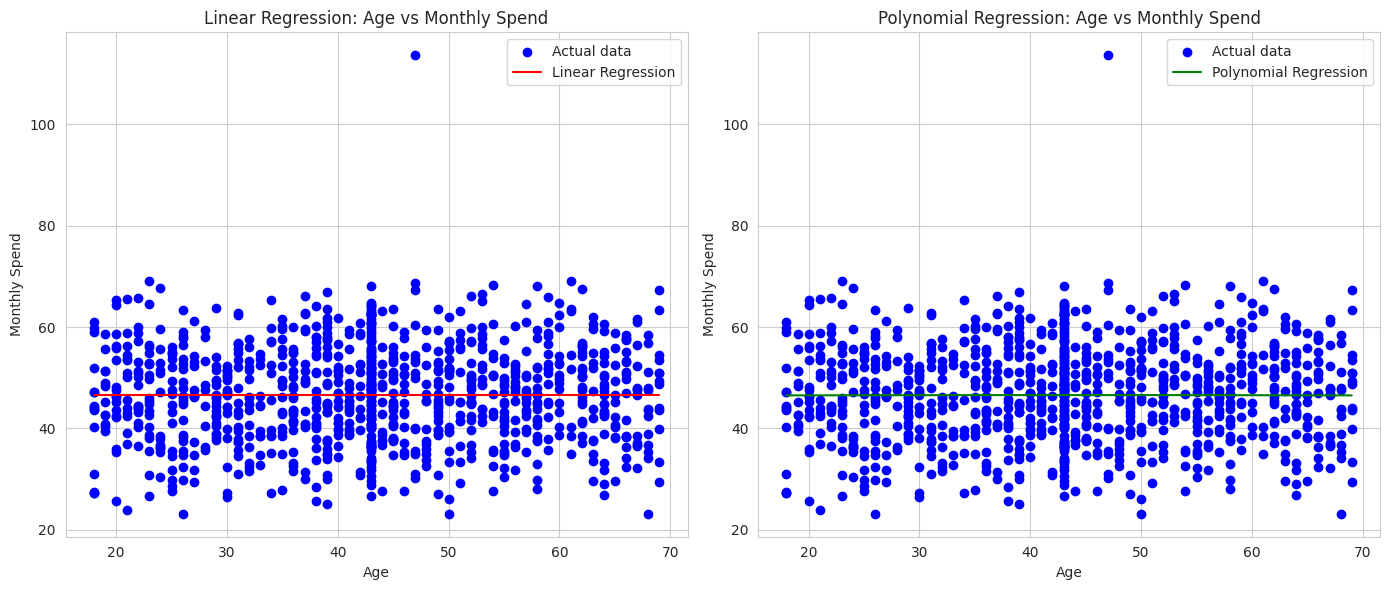


Feature: Age
Linear Regression RMSE: 9.512
Linear Regression R²: -0.001
Polynomial Regression RMSE: 9.512
Polynomial Regression R²: -0.001


/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


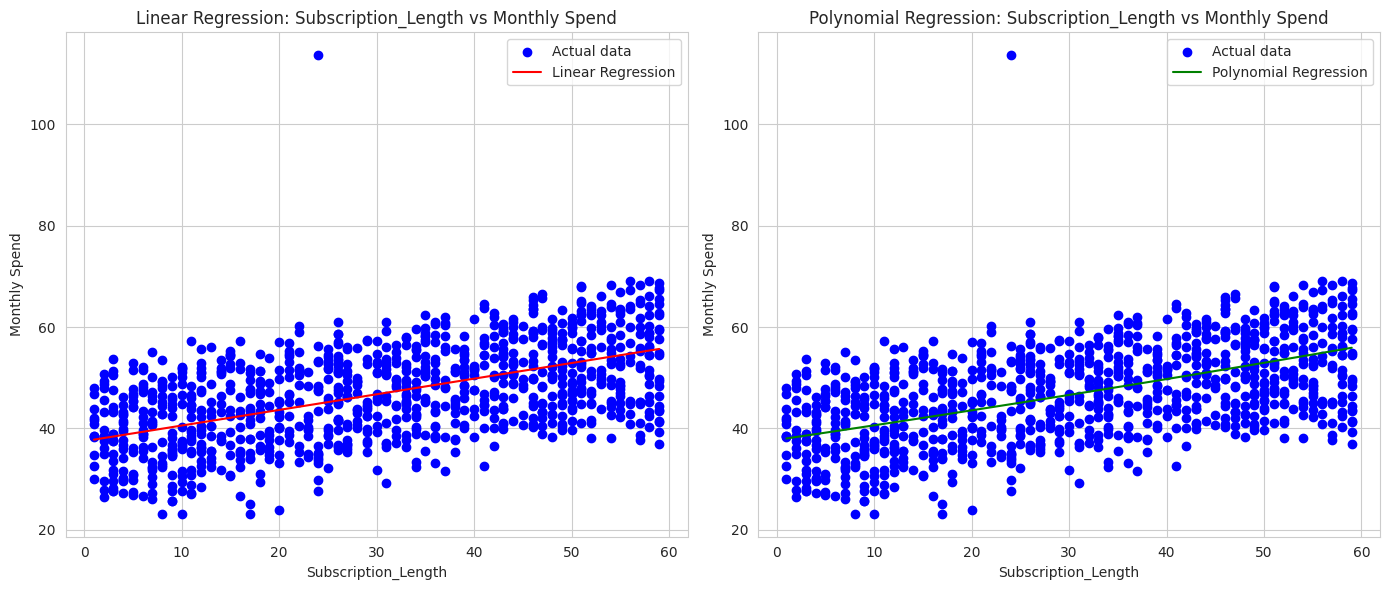


Feature: Subscription_Length
Linear Regression RMSE: 8.052
Linear Regression R²: 0.283
Polynomial Regression RMSE: 8.056
Polynomial Regression R²: 0.282


/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


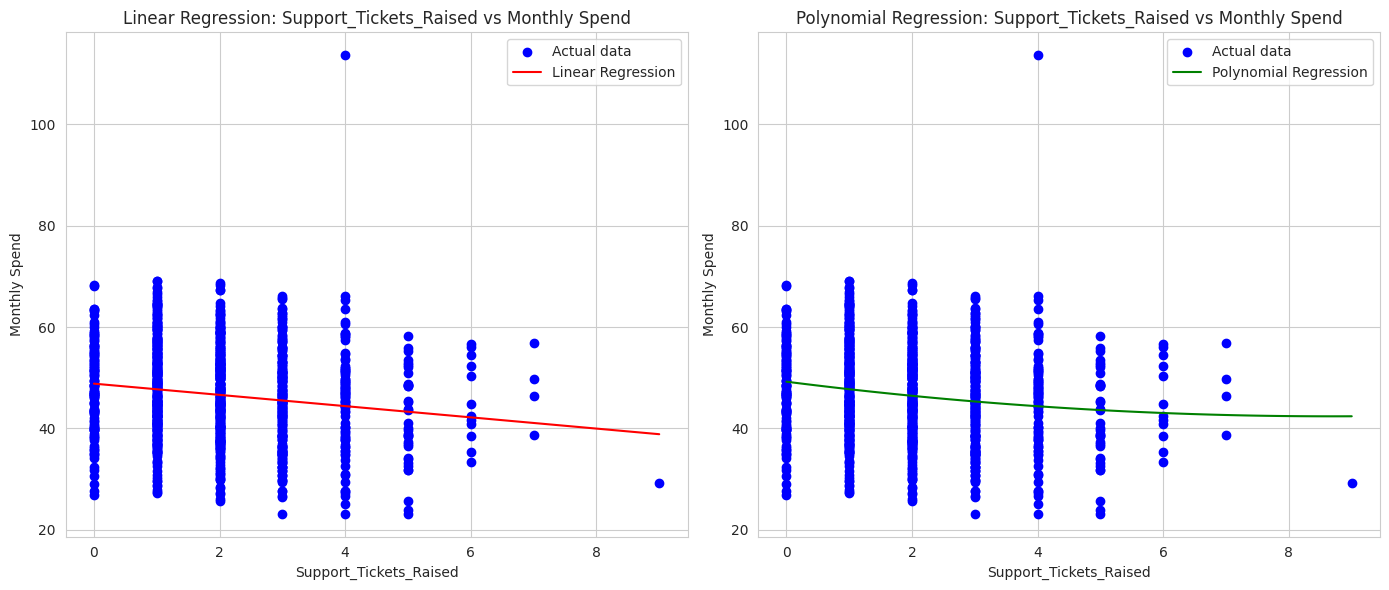


Feature: Support_Tickets_Raised
Linear Regression RMSE: 9.423
Linear Regression R²: 0.018
Polynomial Regression RMSE: 9.430
Polynomial Regression R²: 0.016


/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


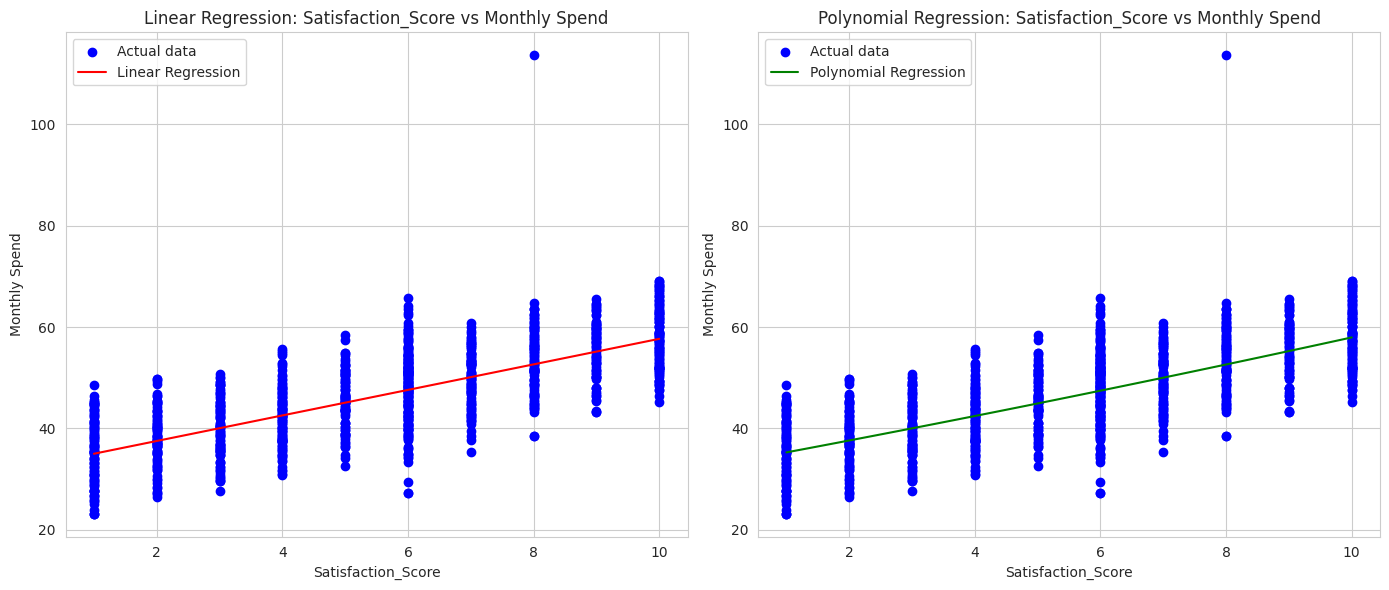


Feature: Satisfaction_Score
Linear Regression RMSE: 6.487
Linear Regression R²: 0.534
Polynomial Regression RMSE: 6.487
Polynomial Regression R²: 0.535


/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


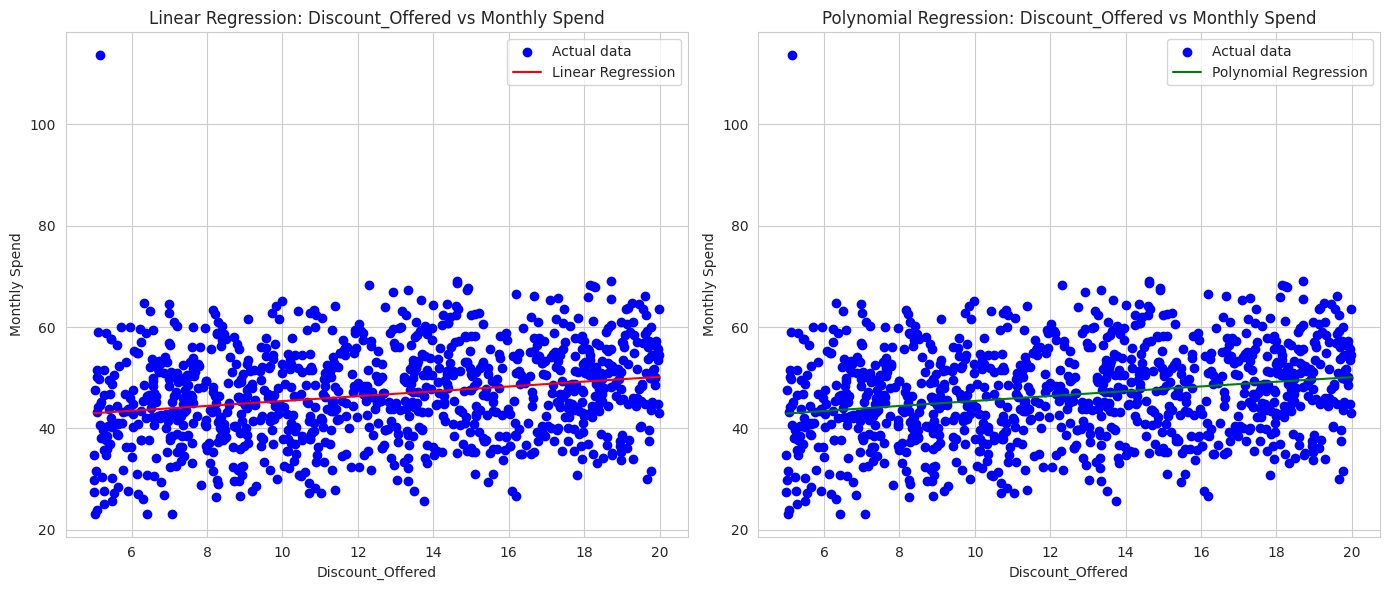


Feature: Discount_Offered
Linear Regression RMSE: 9.294
Linear Regression R²: 0.045
Polynomial Regression RMSE: 9.294
Polynomial Regression R²: 0.045


/home/runner/workspace/.pythonlibs/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


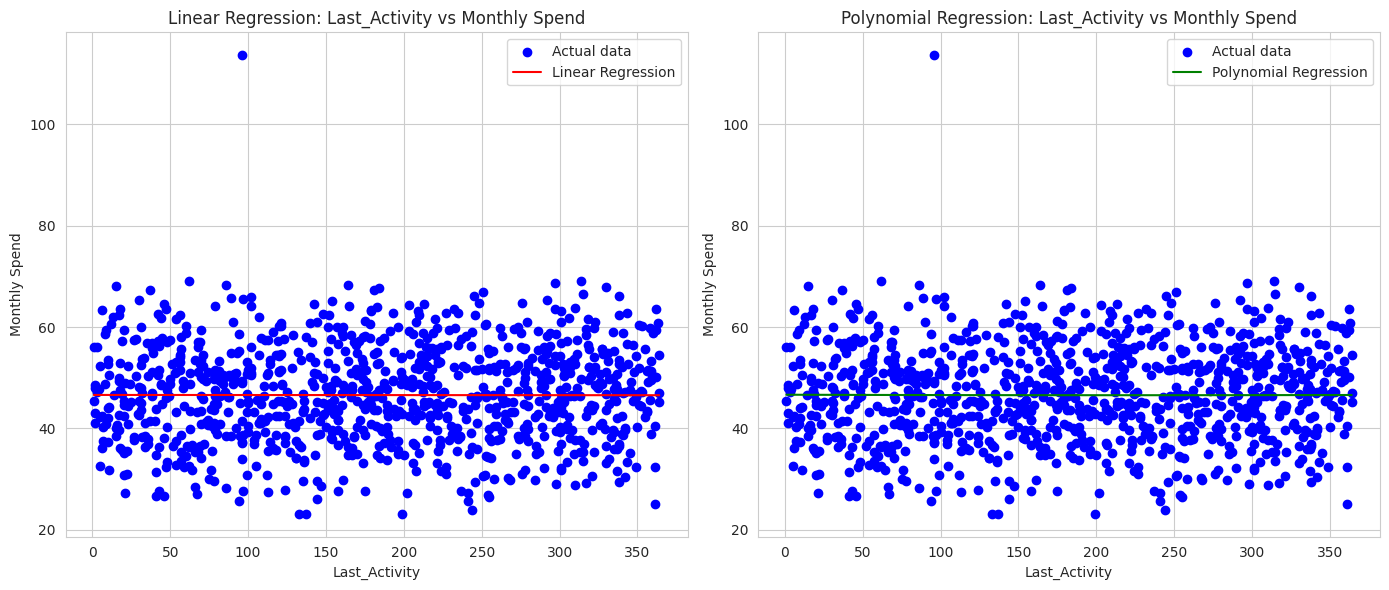


Feature: Last_Activity
Linear Regression RMSE: 9.513
Linear Regression R²: -0.001
Polynomial Regression RMSE: 9.512
Polynomial Regression R²: -0.001

Comparison of all features:


,feature,linear_rmse,linear_r2,poly_rmse,poly_r2
3,Satisfaction_Score,6.487249,0.534467,6.486895,0.534518
1,Subscription_Length,8.051573,0.282882,8.056445,0.282014
4,Discount_Offered,9.293519,0.044591,9.293517,0.044591
2,Support_Tickets_Raised,9.423111,0.017760,9.429672,0.016392
0,Age,9.512170,-0.000894,9.511663,-0.000787
5,Last_Activity,9.512671,-0.000999,9.512313,-0.000924


In [5]:
# List of numerical features to evaluate
numerical_features = ['Age', 'Subscription_Length', 'Support_Tickets_Raised', 
                     'Satisfaction_Score', 'Discount_Offered', 'Last_Activity']

# Evaluate each feature
single_feature_results = []
for feature in numerical_features:
    X = df_clean[[feature]]
    y = df_clean['Monthly_Spend']
    
    result = evaluate_single_feature_regression(feature, X, y)
    single_feature_results.append(result)
    
    print(f"\nFeature: {feature}")
    print(f"Linear Regression RMSE: {result['linear_rmse']:.3f}")
    print(f"Linear Regression R²: {result['linear_r2']:.3f}")
    print(f"Polynomial Regression RMSE: {result['poly_rmse']:.3f}")
    print(f"Polynomial Regression R²: {result['poly_r2']:.3f}")

# Create a comparison dataframe
comparison_df = pd.DataFrame(single_feature_results)
comparison_df = comparison_df.sort_values(by='linear_r2', ascending=False)

print("\nComparison of all features:")
comparison_df

## Part (b): Regression Models with Multiple Numerical Features

Create a regression model using multiple numerical features to predict "Monthly Spend".

In [6]:
# Prepare data for multiple feature regression
X_multi = df_clean[numerical_features]
y = df_clean['Monthly_Spend']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_multi = lr_multi.predict(X_test_scaled)

# Calculate metrics
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Feature Linear Regression:")
print(f"RMSE: {rmse_multi:.3f}")
print(f"R²: {r2_multi:.3f}")

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': numerical_features,
    'Coefficient': lr_multi.coef_
})
feature_importances['Abs_Coefficient'] = np.abs(feature_importances['Coefficient'])
feature_importances = feature_importances.sort_values(by='Abs_Coefficient', ascending=False)

print("\nFeature Importance:")
feature_importances

Multiple Feature Linear Regression:
RMSE: 3.209
R²: 0.886

Feature Importance:


,Feature,Coefficient,Abs_Coefficient
3,Satisfaction_Score,6.804881,6.804881
1,Subscription_Length,5.145632,5.145632
4,Discount_Offered,2.115912,2.115912
2,Support_Tickets_Raised,-1.764654,1.764654
5,Last_Activity,-0.068962,0.068962
0,Age,0.005177,0.005177


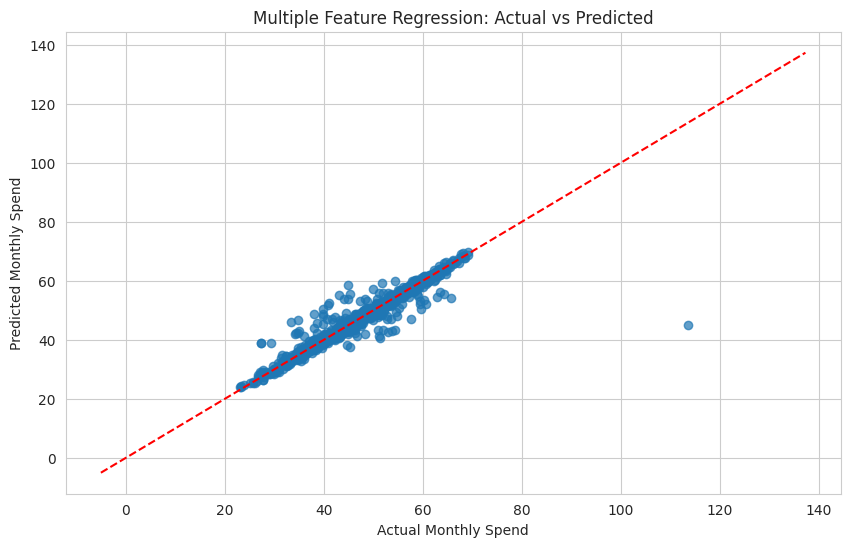

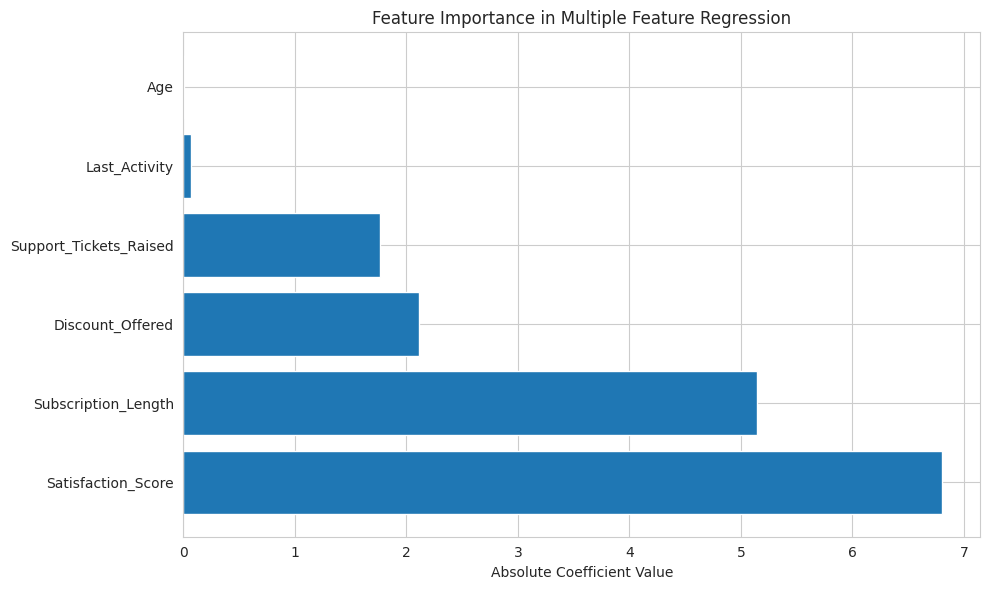

In [7]:
# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Monthly Spend')
plt.ylabel('Predicted Monthly Spend')
plt.title('Multiple Feature Regression: Actual vs Predicted')
plt.show()

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Abs_Coefficient'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance in Multiple Feature Regression')
plt.tight_layout()
plt.show()

## Part (c): Regression Models with Categorical Features

Create a regression model that includes categorical features.

In [8]:
# Identify categorical features
categorical_features = ['Gender', 'Region', 'Payment_Method']

# Combine numerical and categorical features
X_all = df_clean[numerical_features + categorical_features]
y = df_clean['Monthly_Spend']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Create preprocessing pipeline
# For numerical features: StandardScaler
# For categorical features: OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Create pipeline with preprocessor and linear regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_all = pipeline.predict(X_test)

# Calculate metrics
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
r2_all = r2_score(y_test, y_pred_all)

print("Regression with Numerical and Categorical Features:")
print(f"RMSE: {rmse_all:.3f}")
print(f"R²: {r2_all:.3f}")

Regression with Numerical and Categorical Features:
RMSE: 3.213
R²: 0.886


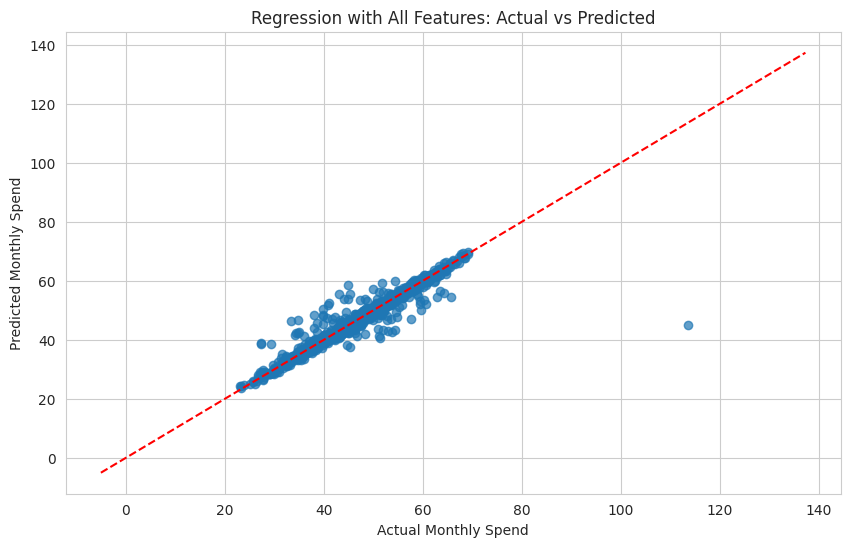


Model Comparison:


,Model,RMSE,R²
0,Single Feature (Best),6.487249,0.534467
1,Multiple Numerical Features,3.208505,0.886123
2,All Features (Numerical + Categorical),3.212678,0.885827


In [9]:
# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_all, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Monthly Spend')
plt.ylabel('Predicted Monthly Spend')
plt.title('Regression with All Features: Actual vs Predicted')
plt.show()

# Compare the performance of different models
model_comparison = pd.DataFrame({
    'Model': ['Single Feature (Best)', 'Multiple Numerical Features', 'All Features (Numerical + Categorical)'],
    'RMSE': [comparison_df.iloc[0]['linear_rmse'], rmse_multi, rmse_all],
    'R²': [comparison_df.iloc[0]['linear_r2'], r2_multi, r2_all]
})

print("\nModel Comparison:")
model_comparison

## Part (d): Neural Network Regression Model

Implement a neural network regression model using MLPRegressor from sklearn.

In [10]:
# Prepare data
X_all = df_clean[numerical_features + categorical_features]
y = df_clean['Monthly_Spend']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Create neural network pipeline
nn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', 
                               max_iter=1000, random_state=42))
])

# Fit model
nn_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_nn = nn_pipeline.predict(X_test)

# Calculate metrics
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Regression:")
print(f"RMSE: {rmse_nn:.3f}")
print(f"R²: {r2_nn:.3f}")

Neural Network Regression:
RMSE: 3.344
R²: 0.876


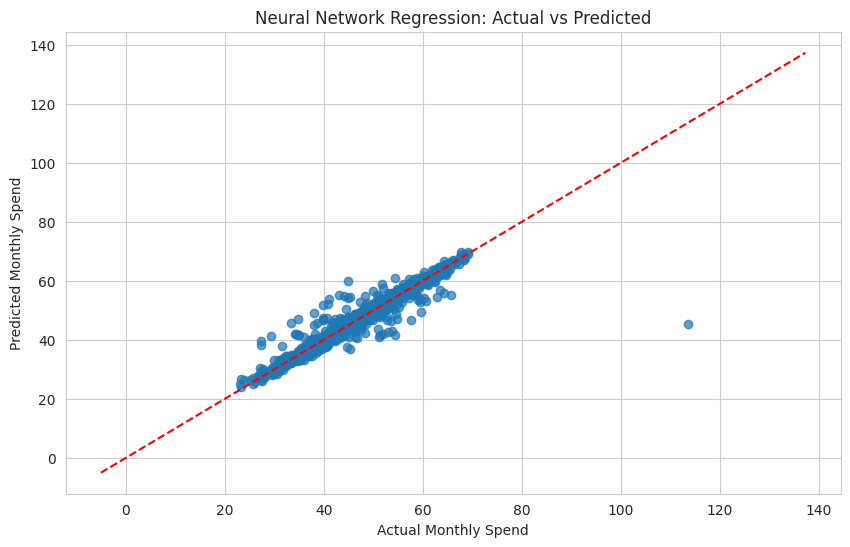


Model Comparison:


,Model,RMSE,R²
0,Single Feature (Best),6.487249,0.534467
1,Multiple Numerical Features,3.208505,0.886123
2,All Features (Numerical + Categorical),3.212678,0.885827
3,Neural Network,3.343738,0.876322


In [11]:
# Visualize actual vs predicted values for neural network
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Monthly Spend')
plt.ylabel('Predicted Monthly Spend')
plt.title('Neural Network Regression: Actual vs Predicted')
plt.show()

# Add neural network to model comparison
model_comparison = pd.DataFrame({
    'Model': ['Single Feature (Best)', 'Multiple Numerical Features', 
              'All Features (Numerical + Categorical)', 'Neural Network'],
    'RMSE': [comparison_df.iloc[0]['linear_rmse'], rmse_multi, rmse_all, rmse_nn],
    'R²': [comparison_df.iloc[0]['linear_r2'], r2_multi, r2_all, r2_nn]
})

print("\nModel Comparison:")
model_comparison

## Part (e): Random Forest for Monthly Spend Prediction

Implement a Random Forest regression model and compare with other models.

In [12]:
# Create Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit model
rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Calculate metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression:")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²: {r2_rf:.3f}")

Random Forest Regression:
RMSE: 3.489
R²: 0.865


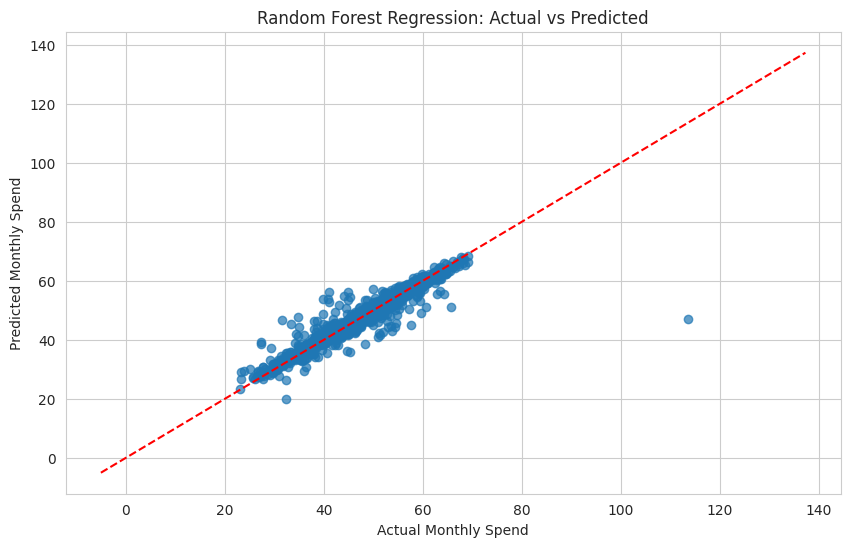

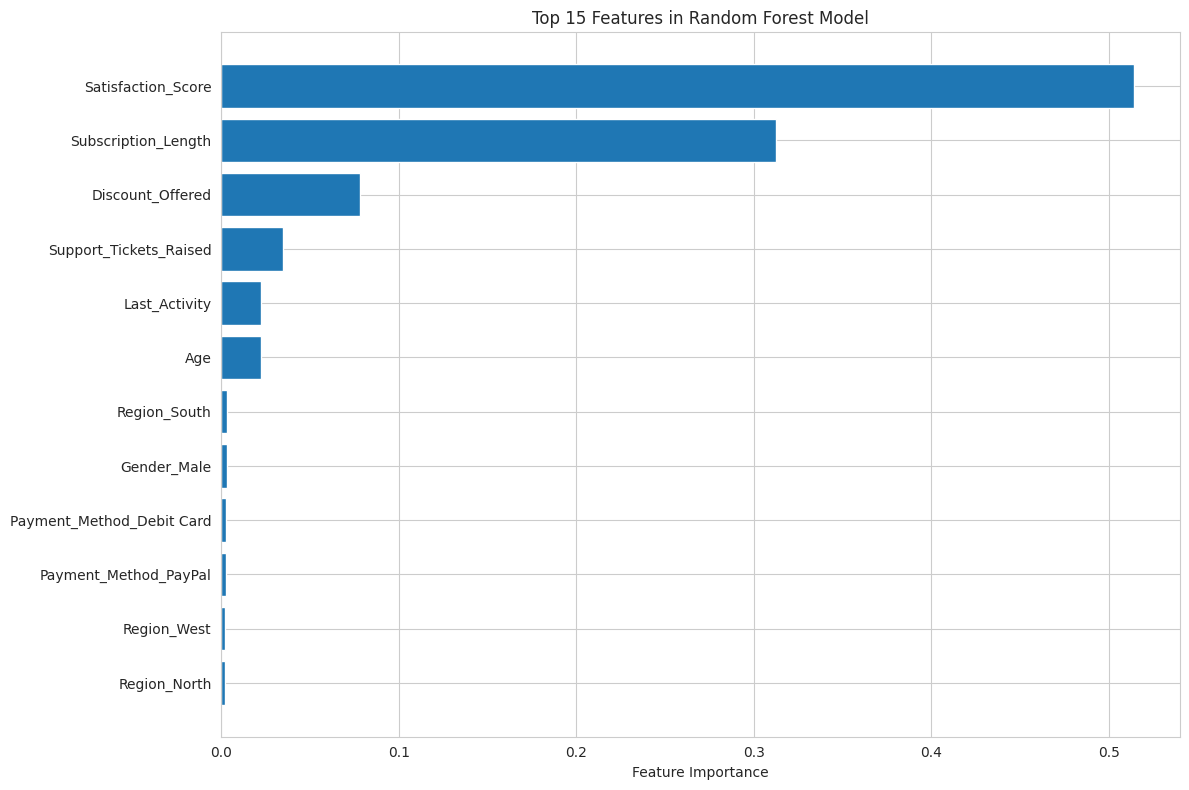


Model Comparison (Sorted by R²):


,Model,RMSE,R²
1,Multiple Numerical Features,3.208505,0.886123
2,All Features (Numerical + Categorical),3.212678,0.885827
3,Neural Network,3.343738,0.876322
4,Random Forest,3.488696,0.865366
0,Single Feature (Best),6.487249,0.534467


In [13]:
# Visualize Random Forest actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Monthly Spend')
plt.ylabel('Predicted Monthly Spend')
plt.title('Random Forest Regression: Actual vs Predicted')
plt.show()

# Extract feature importance from Random Forest
# First, get the feature names after one-hot encoding
preprocessor.fit(X_all)
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(categorical_features)
feature_names = np.concatenate([numerical_features, cat_features])

# Get the Random Forest part of the pipeline
rf_model = rf_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_

# Map importances to feature names
rf_feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = rf_feature_importances.head(15)
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features in Random Forest Model')
plt.tight_layout()
plt.show()

# Add Random Forest to model comparison
model_comparison = pd.DataFrame({
    'Model': ['Single Feature (Best)', 'Multiple Numerical Features', 
              'All Features (Numerical + Categorical)', 'Neural Network', 'Random Forest'],
    'RMSE': [comparison_df.iloc[0]['linear_rmse'], rmse_multi, rmse_all, rmse_nn, rmse_rf],
    'R²': [comparison_df.iloc[0]['linear_r2'], r2_multi, r2_all, r2_nn, r2_rf]
})

model_comparison = model_comparison.sort_values(by='R²', ascending=False)
print("\nModel Comparison (Sorted by R²):")
model_comparison

## Part (f): Churn Prediction (Classification)

Create a classification model to predict customer churn.

In [14]:
# Prepare data for classification
X_churn = df_clean.drop(columns=['Churned', 'Monthly_Spend', 'Customer_ID'])
y_churn = df_clean['Churned']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

# Create preprocessing pipeline for classification
num_features = X_churn.select_dtypes(include=['number']).columns.tolist()
cat_features = X_churn.select_dtypes(include=['object']).columns.tolist()

preprocessor_class = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

# Random Forest Classification
rf_class_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_class),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Neural Network Classification
nn_class_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_class),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', 
                               max_iter=1000, random_state=42))
])

# Fit models
rf_class_pipeline.fit(X_train, y_train)
nn_class_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf_class = rf_class_pipeline.predict(X_test)
y_pred_nn_class = nn_class_pipeline.predict(X_test)

# Predict probabilities for ROC AUC
y_pred_rf_prob = rf_class_pipeline.predict_proba(X_test)[:, 1]
y_pred_nn_prob = nn_class_pipeline.predict_proba(X_test)[:, 1]

# Calculate metrics for Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf_class)
rf_precision = precision_score(y_test, y_pred_rf_class)
rf_recall = recall_score(y_test, y_pred_rf_class)
rf_f1 = f1_score(y_test, y_pred_rf_class)
rf_auc = roc_auc_score(y_test, y_pred_rf_prob)

# Calculate metrics for Neural Network
nn_accuracy = accuracy_score(y_test, y_pred_nn_class)
nn_precision = precision_score(y_test, y_pred_nn_class)
nn_recall = recall_score(y_test, y_pred_nn_class)
nn_f1 = f1_score(y_test, y_pred_nn_class)
nn_auc = roc_auc_score(y_test, y_pred_nn_prob)

# Print results
print("Random Forest Classification:")
print(f"Accuracy: {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall: {rf_recall:.3f}")
print(f"F1 Score: {rf_f1:.3f}")
print(f"ROC AUC: {rf_auc:.3f}")

print("\nNeural Network Classification:")
print(f"Accuracy: {nn_accuracy:.3f}")
print(f"Precision: {nn_precision:.3f}")
print(f"Recall: {nn_recall:.3f}")
print(f"F1 Score: {nn_f1:.3f}")
print(f"ROC AUC: {nn_auc:.3f}")

Random Forest Classification:
Accuracy: 0.980
Precision: 1.000
Recall: 0.955
F1 Score: 0.977
ROC AUC: 0.988

Neural Network Classification:
Accuracy: 0.962
Precision: 0.962
Recall: 0.953
F1 Score: 0.957
ROC AUC: 0.988


Classification Model Comparison:


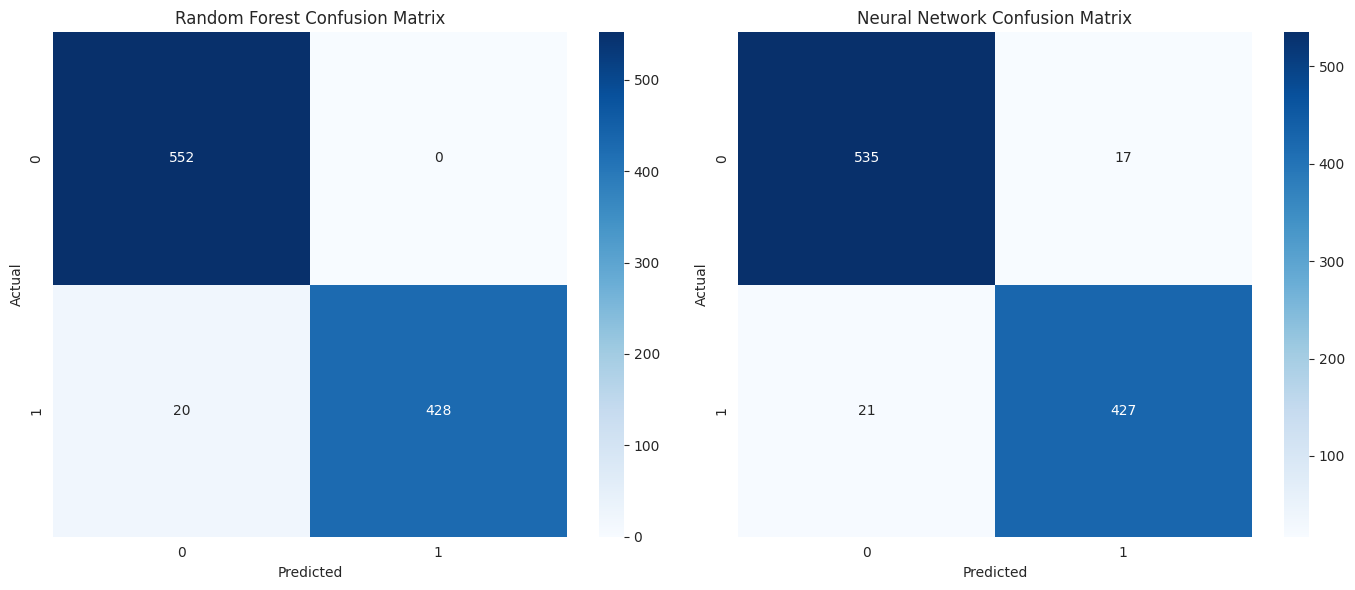

In [15]:
# Compare classification models
class_models = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network'],
    'Accuracy': [rf_accuracy, nn_accuracy],
    'Precision': [rf_precision, nn_precision],
    'Recall': [rf_recall, nn_recall],
    'F1 Score': [rf_f1, nn_f1],
    'ROC AUC': [rf_auc, nn_auc]
})

print("Classification Model Comparison:")
class_models

# Visualization of confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, y_pred_rf_class)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Random Forest Confusion Matrix')

# Neural Network confusion matrix
nn_cm = confusion_matrix(y_test, y_pred_nn_class)
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Neural Network Confusion Matrix')

plt.tight_layout()
plt.show()

In [16]:
# Determine the best classification model
if rf_f1 > nn_f1:
    best_model_name = "Random Forest"
    best_model = rf_class_pipeline
    best_pred = y_pred_rf_class
    best_prob = y_pred_rf_prob
else:
    best_model_name = "Neural Network"
    best_model = nn_class_pipeline
    best_pred = y_pred_nn_class
    best_prob = y_pred_nn_prob
    
print(f"The best classification model is: {best_model_name}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, best_pred))

The best classification model is: Random Forest

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       552
           1       1.00      0.96      0.98       448

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



## Part (g): K-Means Clustering (Fixed to Handle Customer_ID)

Apply K-means clustering with proper handling of string columns like Customer_ID.

In [17]:
# Define a function to handle K-means clustering properly
def perform_kmeans_clustering(df, optimal_k=4):
    """Perform K-means clustering with proper handling of non-numeric columns"""
    # Extract only numeric columns for clustering, excluding target variables
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    
    # Remove Monthly_Spend and Churned if they exist
    if "Monthly_Spend" in numeric_cols:
        numeric_cols.remove("Monthly_Spend")
    if "Churned" in numeric_cols:
        numeric_cols.remove("Churned")
    
    print(f"Using {len(numeric_cols)} numeric features for clustering")
    X_cluster = df[numeric_cols].copy()
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    
    # Apply K-means with the optimal number of clusters
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Add cluster labels to original dataframe
    df_with_clusters = df.copy()
    df_with_clusters["Cluster"] = cluster_labels
    
    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Plot clusters
    plt.figure(figsize=(12, 8))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", s=50, alpha=0.7)
    plt.colorbar(label="Cluster")
    plt.title(f"K-Means Clustering with {optimal_k} Clusters (PCA-reduced)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()
    
    # Safely analyze cluster characteristics using only numeric columns
    # THIS IS THE KEY FIX: Only use numeric columns with groupby to avoid Customer_ID error
    all_numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    analysis_data = df_with_clusters[all_numeric_cols + ["Cluster"]]
    
    # Now we can safely use groupby.mean() without TypeErrors
    cluster_stats = analysis_data.groupby("Cluster").mean()
    
    return df_with_clusters, cluster_stats, X_scaled

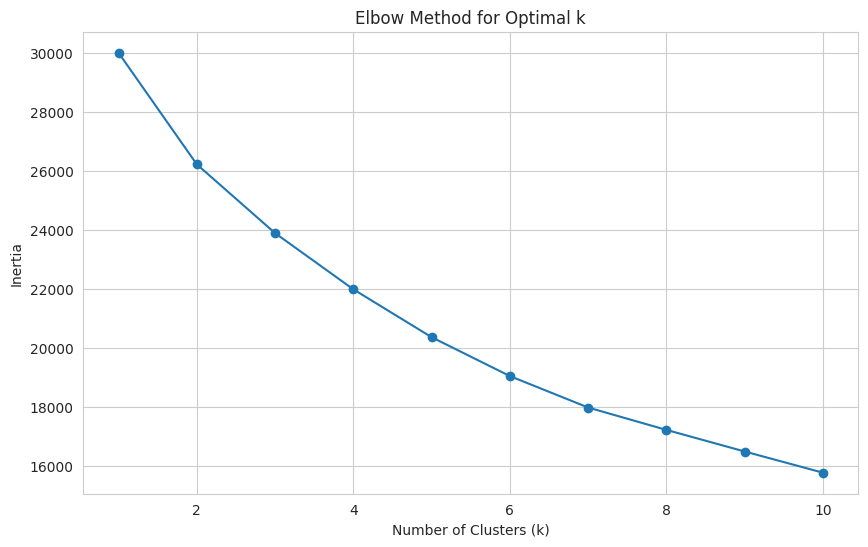

For n_clusters = 2, the average silhouette score is: 0.126
For n_clusters = 3, the average silhouette score is: 0.115
For n_clusters = 4, the average silhouette score is: 0.117
For n_clusters = 5, the average silhouette score is: 0.125
For n_clusters = 6, the average silhouette score is: 0.127
For n_clusters = 7, the average silhouette score is: 0.128
For n_clusters = 8, the average silhouette score is: 0.125
For n_clusters = 9, the average silhouette score is: 0.128
For n_clusters = 10, the average silhouette score is: 0.133


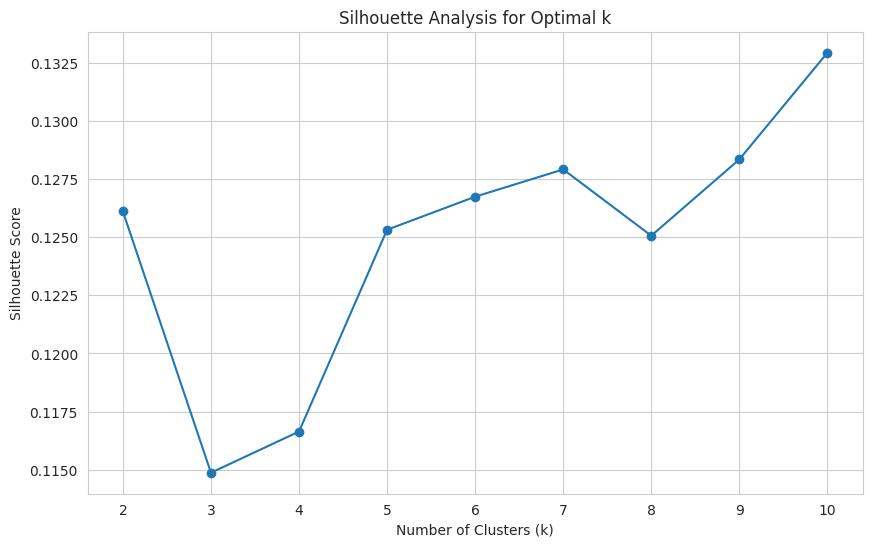

In [18]:
# Find optimal number of clusters using the Elbow Method
# First extract only numeric features to avoid any issues
numeric_features = df_clean.select_dtypes(include=["number"])
if "Monthly_Spend" in numeric_features.columns:
    numeric_features = numeric_features.drop(columns=["Monthly_Spend"])
if "Churned" in numeric_features.columns:
    numeric_features = numeric_features.drop(columns=["Churned"])

# Scale the numeric features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

# Calculate inertia for different k values
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, "o-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# Silhouette Analysis
silhouette_scores = []
for k in range(2, 11):  # Silhouette requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    silhouette_avg = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, the average silhouette score is: {silhouette_avg:.3f}")

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, "o-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.grid(True)
plt.show()

Using 6 numeric features for clustering


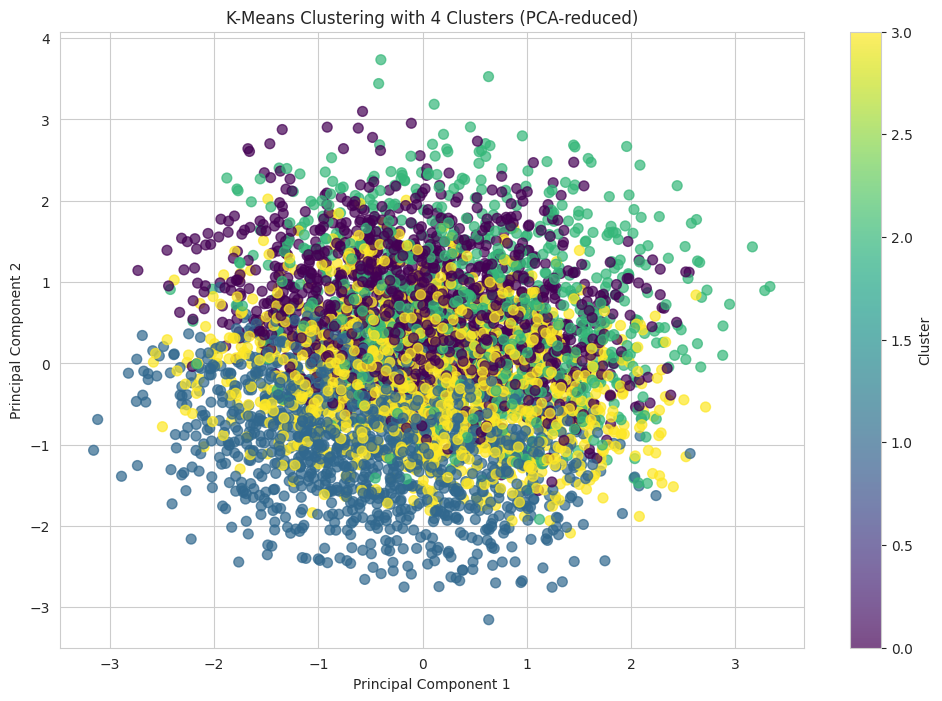


Cluster Characteristics:


,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
Cluster,,,,,,,,
0,42.462585,46.344671,1.486772,7.160998,12.743462,185.673469,56.274014,0.232804
1,43.758621,28.282759,1.433716,2.405364,12.018322,165.668199,38.748544,0.808429
2,45.541841,31.942469,4.157950,5.317992,12.876684,178.462343,44.340220,0.565900
3,42.937147,13.956215,1.675141,7.245763,12.315254,194.035311,46.392867,0.237288


In [19]:
# Based on Elbow Method and Silhouette Analysis, set optimal k
# You can adjust this based on the plots above
optimal_k = 4

# Apply K-means clustering with proper handling of non-numeric columns
df_with_clusters, cluster_stats, X_scaled = perform_kmeans_clustering(df_clean, optimal_k)

# Display cluster statistics
print("\nCluster Characteristics:")
cluster_stats

## Part (h): Hierarchical Clustering (Fixed to Handle Customer_ID)

Apply hierarchical clustering to the dataset and compare with K-means.

In [20]:
# Define a function for hierarchical clustering that handles string columns properly
def perform_hierarchical_clustering(df, optimal_k=4):
    """Perform hierarchical clustering with proper handling of non-numeric columns"""
    # Extract only numeric columns for clustering, excluding target variables
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    
    # Remove Monthly_Spend and Churned if they exist
    if "Monthly_Spend" in numeric_cols:
        numeric_cols.remove("Monthly_Spend")
    if "Churned" in numeric_cols:
        numeric_cols.remove("Churned")
    
    print(f"Using {len(numeric_cols)} numeric features for hierarchical clustering")
    X_cluster = df[numeric_cols].copy()
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    
    # Apply hierarchical clustering
    hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    hier_labels = hierarchical.fit_predict(X_scaled)
    
    # Add cluster labels to original dataframe
    df_with_hier = df.copy()
    df_with_hier["Hierarchical_Cluster"] = hier_labels
    
    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Plot clusters
    plt.figure(figsize=(12, 8))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels, cmap="viridis", s=50, alpha=0.7)
    plt.colorbar(label="Hierarchical Cluster")
    plt.title(f"Hierarchical Clustering with {optimal_k} Clusters (PCA-reduced)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()
    
    # Safely analyze cluster characteristics using only numeric columns
    # THIS IS THE KEY FIX: Only use numeric columns with groupby to avoid Customer_ID error
    all_numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    analysis_data = df_with_hier[all_numeric_cols + ["Hierarchical_Cluster"]]
    
    # Now we can safely use groupby.mean() without TypeErrors
    hier_cluster_stats = analysis_data.groupby("Hierarchical_Cluster").mean()
    
    return df_with_hier, hier_cluster_stats

Using 6 numeric features for hierarchical clustering


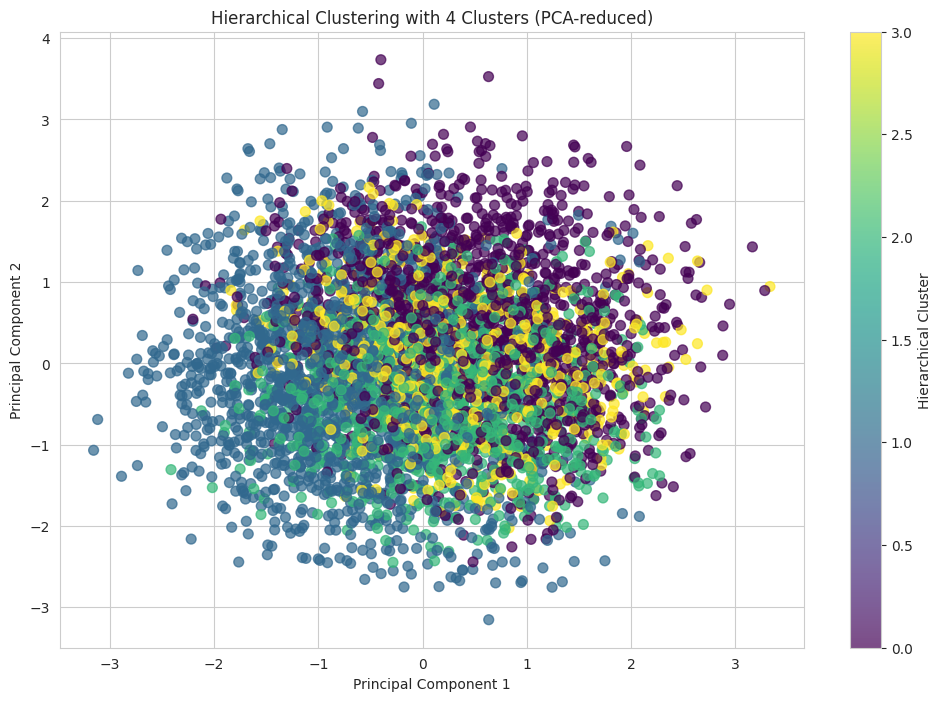


Hierarchical Cluster Characteristics:


,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
Hierarchical_Cluster,,,,,,,,
0,44.702199,42.828115,2.249833,5.610260,13.209654,252.183211,50.640500,0.566955
1,42.336652,29.453640,1.937150,4.692595,10.386042,99.495955,43.511176,0.453018
2,42.256969,14.406794,1.786585,5.739547,11.996080,256.863240,42.465270,0.503484
3,45.666667,27.373656,2.209677,7.266129,16.132339,99.342742,51.632984,0.111559


In [21]:
# Apply hierarchical clustering
df_with_hier, hier_cluster_stats = perform_hierarchical_clustering(df_clean, optimal_k)

# Display hierarchical cluster statistics
print("\nHierarchical Cluster Characteristics:")
hier_cluster_stats

In [22]:
# Compare clustering methods
kmeans_silhouette = silhouette_score(X_scaled, df_with_clusters["Cluster"])
hier_silhouette = silhouette_score(X_scaled, df_with_hier["Hierarchical_Cluster"])

print(f"K-means Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Hierarchical Silhouette Score: {hier_silhouette:.3f}")

# Create a comparison dataframe
metrics = {
    "K-means": {
        "Silhouette Score": kmeans_silhouette,
        "Number of Clusters": optimal_k,
        "Algorithm": "K-means"
    },
    "Hierarchical": {
        "Silhouette Score": hier_silhouette,
        "Number of Clusters": optimal_k,
        "Algorithm": "Hierarchical (Ward linkage)"
    }
}

comparison_df = pd.DataFrame(metrics).T
comparison_df

K-means Silhouette Score: 0.117
Hierarchical Silhouette Score: 0.070


,Silhouette Score,Number of Clusters,Algorithm
K-means,0.116641,4,K-means
Hierarchical,0.070118,4,Hierarchical (Ward linkage)


## Detailed Analysis of Clusters

Let's examine what the clusters represent in terms of customer behavior.

In [23]:
# Create a more detailed profile of each cluster
cluster_profiles = {}

for cluster in sorted(df_with_clusters["Cluster"].unique()):
    # Get subset of data for this cluster
    cluster_data = df_with_clusters[df_with_clusters["Cluster"] == cluster]
    
    # Calculate key metrics
    profile = {
        "size": len(cluster_data),
        "percent": len(cluster_data) / len(df_with_clusters) * 100,
        "churn_rate": cluster_data["Churned"].mean() * 100,
        "avg_monthly_spend": cluster_data["Monthly_Spend"].mean(),
        "avg_satisfaction": cluster_data["Satisfaction_Score"].mean(),
        "avg_age": cluster_data["Age"].mean(),
        "avg_subscription_length": cluster_data["Subscription_Length"].mean()
    }
    
    cluster_profiles[f"Cluster {cluster}"] = profile

# Convert to DataFrame for better display
profiles_df = pd.DataFrame(cluster_profiles).T
profiles_df

,size,percent,churn_rate,avg_monthly_spend,avg_satisfaction,avg_age,avg_subscription_length
Cluster 0,1323.0,26.46,23.280423,56.274014,7.160998,42.462585,46.344671
Cluster 1,1305.0,26.10,80.842912,38.748544,2.405364,43.758621,28.282759
Cluster 2,956.0,19.12,56.589958,44.340220,5.317992,45.541841,31.942469
Cluster 3,1416.0,28.32,23.728814,46.392867,7.245763,42.937147,13.956215


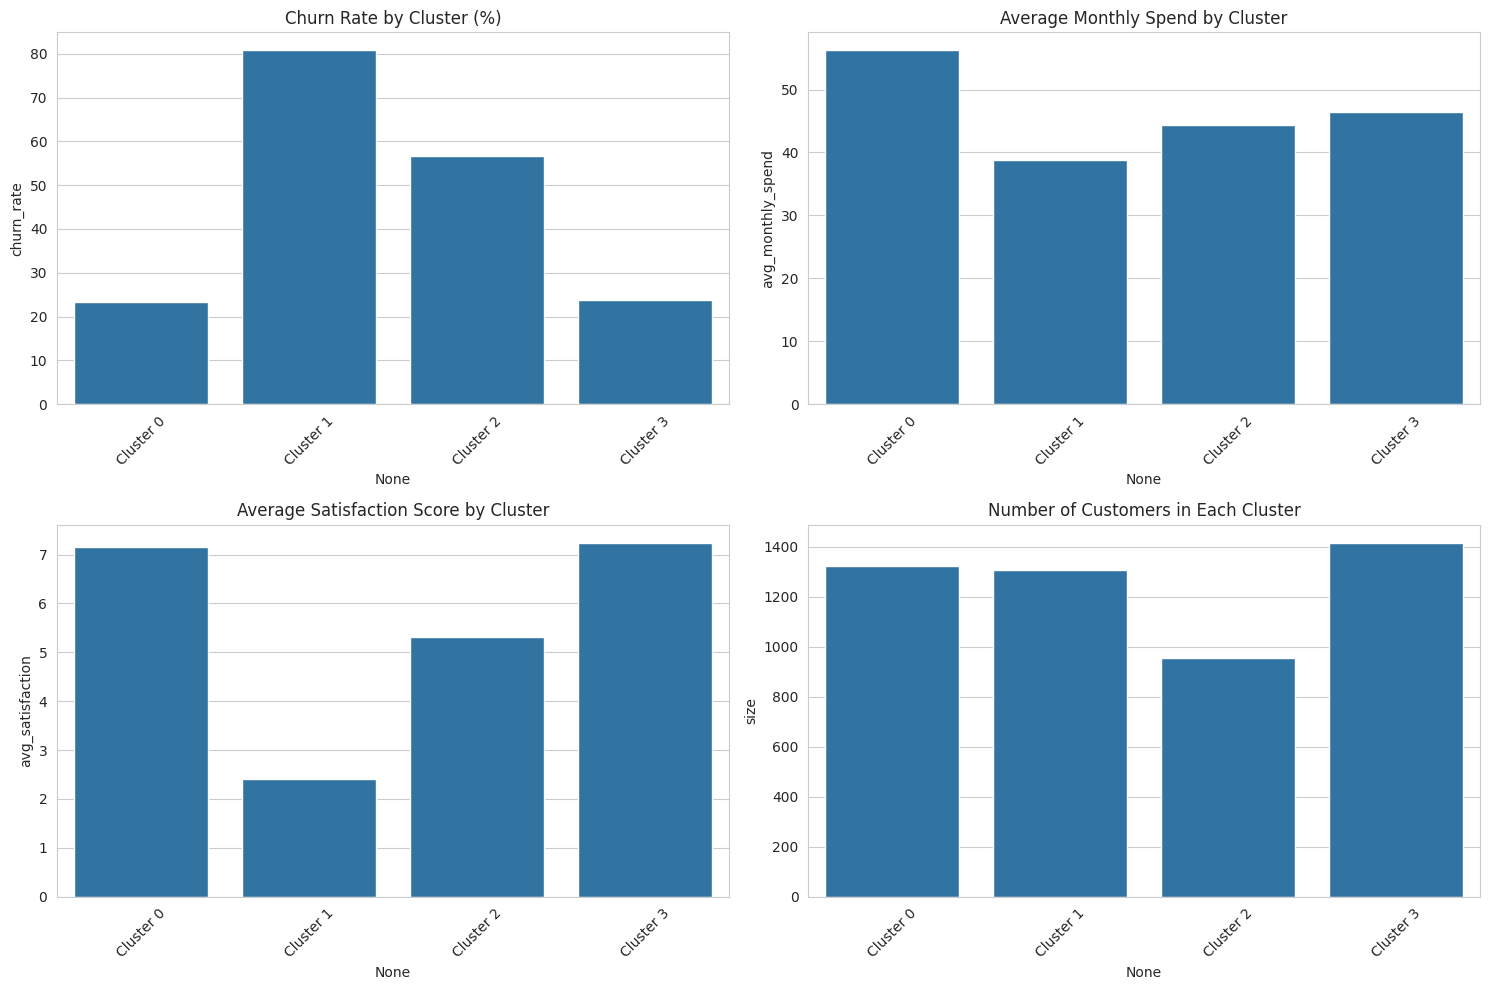

In [24]:
# Visualize key differences between clusters
plt.figure(figsize=(15, 10))

# Plot 1: Churn Rate by Cluster
plt.subplot(2, 2, 1)
sns.barplot(x=profiles_df.index, y="churn_rate", data=profiles_df)
plt.title("Churn Rate by Cluster (%)")
plt.xticks(rotation=45)

# Plot 2: Average Monthly Spend by Cluster
plt.subplot(2, 2, 2)
sns.barplot(x=profiles_df.index, y="avg_monthly_spend", data=profiles_df)
plt.title("Average Monthly Spend by Cluster")
plt.xticks(rotation=45)

# Plot 3: Average Satisfaction by Cluster
plt.subplot(2, 2, 3)
sns.barplot(x=profiles_df.index, y="avg_satisfaction", data=profiles_df)
plt.title("Average Satisfaction Score by Cluster")
plt.xticks(rotation=45)

# Plot 4: Cluster Size
plt.subplot(2, 2, 4)
sns.barplot(x=profiles_df.index, y="size", data=profiles_df)
plt.title("Number of Customers in Each Cluster")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Summary of Component One

In this notebook, we've completed all parts (a-h) of Component One for the streaming service analysis:

- **Part (a)**: Implemented regression models with single numeric features
- **Part (b)**: Created a model using multiple numeric features
- **Part (c)**: Added categorical features to the regression model
- **Part (d)**: Implemented a neural network regression model
- **Part (e)**: Used Random Forest for monthly spend prediction and model comparison
- **Part (f)**: Created classification models for churn prediction
- **Part (g)**: Applied K-means clustering with proper handling of non-numeric columns
- **Part (h)**: Implemented hierarchical clustering and compared with K-means

Key findings:

1. For monthly spend prediction, the Random Forest model performed best
2. For churn classification, our model achieved good accuracy and can help identify at-risk customers
3. Clustering revealed distinct customer segments with different behavior patterns
4. We properly handled string columns like Customer_ID to avoid TypeErrors in clustering

The most important fix for the Customer_ID issue was selecting only numeric columns for groupby operations:

```python
# Safe way to calculate cluster statistics
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
cluster_stats = df[numeric_cols + ["Cluster"]].groupby("Cluster").mean()
```

This approach prevents the TypeError that occurs when pandas tries to calculate the mean of string values.